# 파이썬으로 회귀분석하기 (Kuggle Week_02 실습 과제)

- **I.** 데이터 준비
- **II.** 단순선형회귀 (OLS)
- **III.** 다중선형회귀
- **IV.** 선형회귀의 가정 진단 (선형성 / 독립성 / 정규성 / 등분산성)
- **V.** 회귀 모델 평가 (MSE / RMSE / MAE / R² / Adjusted R²)
- **VI.** 과대적합 & 과소적합 (다항회귀, train/test, 정규화)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# plt에서 마이너스 기호 깨짐 방지
np.random.seed(42)
plt.rcParams["axes.unicode_minus"] = False

## I. 데이터 준비

회귀분석 세션 자료 예시를 그대로 재현: **가계소득(X) → 저축액(Y)**


In [3]:
n = 100
income = np.random.uniform(200, 800, n)  # 가계소득 (만원)
noise = np.random.normal(0, 40, n)
saving = 0.25 * income + 20 + noise  # 저축액 = 0.25*소득 + 20 + 노이즈

df = pd.DataFrame({"income": income, "saving": saving})
df.head()

,income,saving
0,424.724071,129.662901
1,770.428584,200.646852
2,639.196365,183.469522
3,559.195091,80.296016
4,293.611184,84.615921


## II. 단순선형회귀 (OLS)

$\hat y = b_0 + b_1 x$

단순선형회귀 공식을 그대로 손으로 계산해보고, sklearn으로 선형 회귀 모델링

$$b_1 = \dfrac{\sum (x_i-\bar x)(y_i-\bar y)}{\sum (x_i-\bar x)^2}, \qquad b_0 = \bar y - b_1 \bar x$$


Q1. 세션 자료에서 배운 공식을 통해 단순선형회귀의 계수 b0, b1을 계산하는 수식을 작성하세요.

In [5]:
X_1d = df["income"].values # 1D 배열로 저장하여 수동 계산에 사용
y = df["saving"].values

# 단순 회귀 수식 직접 계산
x_bar, y_bar = X_1d.mean(), y.mean()
b1_manual = np.sum((X_1d - x_bar) * (y - y_bar)) / np.sum((X_1d - x_bar) ** 2)
b0_manual = y_bar - b1_manual * x_bar

print(f"[직접 계산]   b0={b0_manual:.3f}, b1={b1_manual:.3f}")

[직접 계산]   b0=34.734, b1=0.219


Q2. 다음은 단순선형회귀 모델링 코드입니다. 빈칸을 채워주세요.

In [8]:
#1. 데이터 준비
X_simple = X_1d.reshape(-1, 1)  #reshape(-1,1): LinearRegression 모델은 X가 2D 배열로 입력되어야 하므로, 이에 맞는 변환 필요
y_simple = y

#2. 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.3, random_state=0)

#3. 단순 회귀 모델 학습
lin_reg_s = LinearRegression().fit(X_train, y_train)

#4. 성능 평가
print("-단순 회귀-")
print("Train R²:", lin_reg_s.score(X_train, y_train))
print("Test R²:", lin_reg_s.score(X_test, y_test))     

-단순 회귀-
Train R²: 0.5436831727782818
Test R²: 0.5111935275378604


## III. 다중선형회귀

독립변수를 추가해서 **(소득, 가족 수) → 저축액**을 예측합니다.


Q3. 다음은 다중선형회귀 코드입니다. 빈칸을 채워주세요.

In [9]:
family_size = np.random.randint(1, 6, n)
saving_multi = 0.25 * income - 8 * family_size + 40 + np.random.normal(0, 35, n)
df["family_size"] = family_size
df["saving_multi"] = saving_multi

#1. 데이터 준비
X_multi = np.column_stack([income, family_size]) # 'income'과 'family_size'를 독립 변수로 사용
y_multi = saving_multi

#2. 데이터 분할
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.3, random_state=0)

#3. 다중 회귀 모델 학습
lin_reg_m = LinearRegression().fit(X_train_m, y_train_m)

#4. 성능 평가
print("-다중 회귀-")
print("Train R²:", lin_reg_m.score(X_train_m, y_train_m))
print("Test R²:", lin_reg_m.score(X_test_m, y_test_m))     

-다중 회귀-
Train R²: 0.6033529827441875
Test R²: 0.515634412369401


## IV. 선형회귀의 가정 진단

다중회귀 모델(`lin_reg_m`)의 잔차로 4가지 가정을 시각적으로 점검합니다.


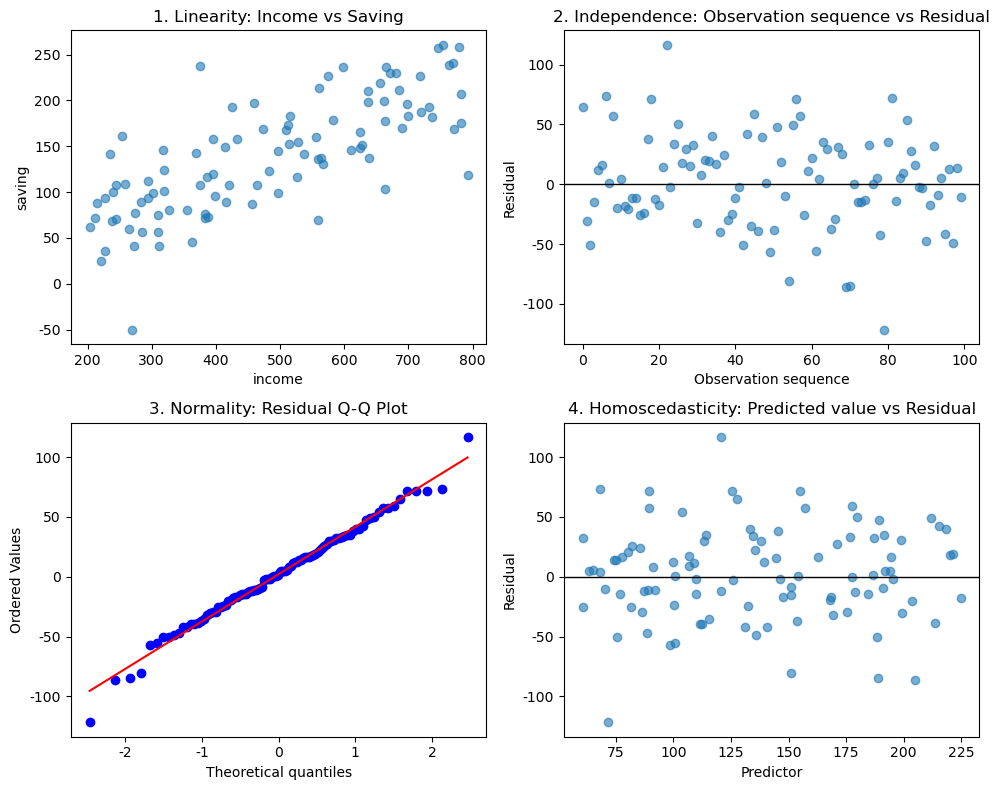

In [10]:
y_pred_multi = lin_reg_m.predict(X_multi)
residuals = y_multi - y_pred_multi

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (1) 선형성(Linearity): 실제 X 중 하나(income) vs y  산점도
axes[0, 0].scatter(df["income"], y_multi, alpha=0.6)
axes[0, 0].set_title("1. Linearity: Income vs Saving")
axes[0, 0].set_xlabel("income")
axes[0, 0].set_ylabel("saving")

# (2) 독립성(Independence): 관측 순서 vs 잔차
axes[0, 1].scatter(range(n), residuals, alpha=0.6)
axes[0, 1].axhline(0, color="black", linewidth=1)
axes[0, 1].set_title("2. Independence: Observation sequence vs Residual")
axes[0, 1].set_xlabel("Observation sequence")
axes[0, 1].set_ylabel("Residual")

# (3) 정규성(Normality): 잔차 Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("3. Normality: Residual Q-Q Plot")

# (4) 등분산성(Homoscedasticity): 예측값 vs 잔차
axes[1, 1].scatter(y_pred_multi, residuals, alpha=0.6)
axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("4. Homoscedasticity: Predicted value vs Residual")
axes[1, 1].set_xlabel("Predictor")
axes[1, 1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

Q4. 위 코드를 그대로 실행해서 4가지 가정(선형성/독립성/정규성/등분산성) 진단 그래프를 그리고,
각 그래프를 보고 가정을 만족하는지 판단해서 아래에 서술하세요.

**답변:**
1. 선형성:Income과 Saving 사이에 우상향하는 선형 관계가 보이므로, 선형성을 가정을 만족함
2. 독립성:잔차들이 특별한 패턴 없이 흩어져 있으므로, 독립성 가정을 만족함
3. 정규성:잔차들이 정규분포를 나타내는 빨간색 선에 거의 일직선으로 밀착되어 있어서, 정규성 가정을 만족함
4. 등분산성:잔차의 분산이 점점 커지거나 작아지는 패턴 없이 일정하게 유지되고 있으므로, 등분산성 가정을 만족함

## V. 회귀 모델 평가

MSE / RMSE / MAE / R² / Adjusted R²


In [ ]:
mse = mean_squared_error(y_multi, y_pred_multi)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_multi, y_pred_multi)
r2 = r2_score(y_multi, y_pred_multi)

# Adjusted R² = 1 - (1-R²)(n-1)/(n-p-1),  p = 독립변수 개수
p = X_multi.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MSE  = {mse:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE  = {mae:.3f}")
print(f"R²   = {r2:.3f}")
print(f"Adjusted R² = {adj_r2:.3f}")

MSE  = 1529.559
RMSE = 39.110
MAE  = 30.673
R²   = 0.599
Adjusted R² = 0.591


## VI. 과대적합 & 과소적합

Q5. 다음은 다항 회귀 차수(degree)를 1->3->15 로 늘려가며 다항회귀를 반복 학습하는 코드입니다. 3개의 그래프가 그려질 텐데, 이 중 어떤 차수의 그래프가 가장 적절한지 고르고 그 이유를 과대적합/과소적합 관점에서 서술하세요.


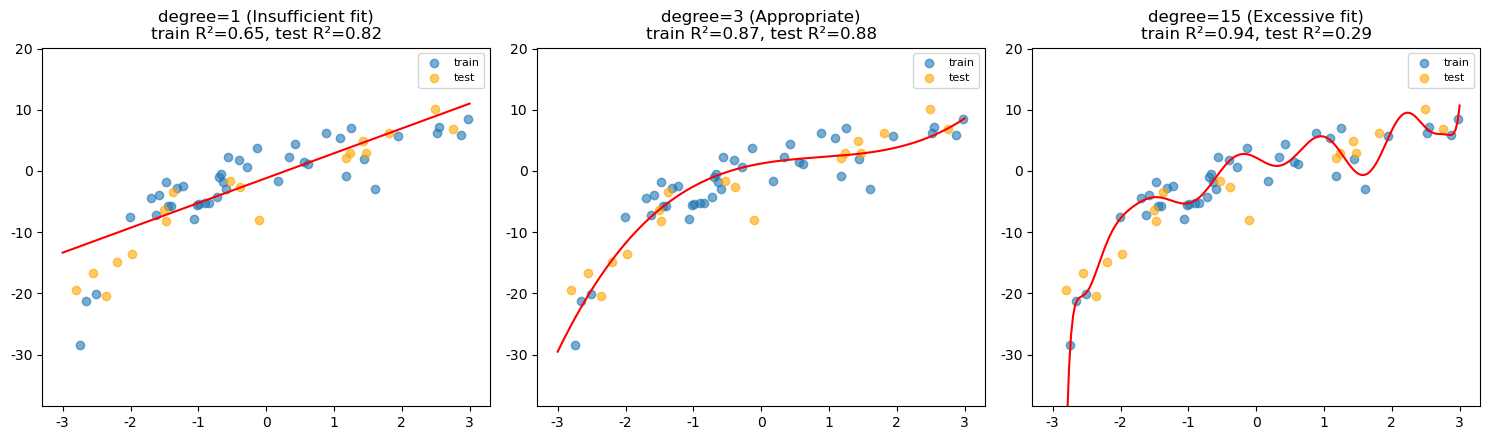

degree= 1 | train R²=0.649 | test R²=0.818
degree= 3 | train R²=0.867 | test R²=0.876
degree=15 | train R²=0.943 | test R²=0.290


In [11]:
# 비선형 관계를 가진 데이터 생성 (다항회귀가 필요한 상황)
x_nl = np.sort(np.random.uniform(-3, 3, 60))
y_nl = 0.5 * x_nl**3 - x_nl**2 + 2 * x_nl + np.random.normal(0, 3, 60)

X_train, X_test, y_train, y_test = train_test_split(
    x_nl.reshape(-1, 1), y_nl, test_size=0.3, random_state=42
)

degrees = [1, 3, 15]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
train_scores, test_scores = [], []

for ax, deg in zip(axes, degrees):
    poly = PolynomialFeatures(degree=deg)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_r2 = model.score(X_train_poly, y_train)
    test_r2 = model.score(X_test_poly, y_test)
    train_scores.append(train_r2)
    test_scores.append(test_r2)

    x_plot = np.linspace(-3, 3, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(x_plot))

    ax.scatter(X_train, y_train, alpha=0.6, label="train")
    ax.scatter(X_test, y_test, alpha=0.6, label="test", color="orange")
    ax.plot(x_plot, y_plot, color="red")
    tag = "Insufficient fit" if deg == 1 else ("Appropriate" if deg == 3 else "Excessive fit")
    ax.set_title(f"degree={deg} ({tag})\ntrain R²={train_r2:.2f}, test R²={test_r2:.2f}")
    ax.set_ylim(y_nl.min() - 10, y_nl.max() + 10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

for deg, tr, te in zip(degrees, train_scores, test_scores):
    print(f"degree={deg:>2} | train R²={tr:.3f} | test R²={te:.3f}")

**답변:** degree=3, 데이터가 전반적인 곡선 형태를 띄고 있으면서 지나치게 굴곡지지 않은 형태를 띄고 있으며, train과 test의 결정계쑤 차이도 거의 없기 때문이다.

### 정규화(L1 / L2)로 과대적합 완화하기

Q6. 다음은 심하게 과대적합된 모델에 Ridge(L2)와 Lasso(L1) 규제를 적용하는 코드입니다. 규제 적용에 따른 결정계수 변화에 대해 서술하세요.


In [12]:
poly15 = PolynomialFeatures(degree=15)
X_train_p15_raw = poly15.fit_transform(X_train)
X_test_p15_raw = poly15.transform(X_test)

scaler = StandardScaler()
X_train_p15 = scaler.fit_transform(X_train_p15_raw)
X_test_p15 = scaler.transform(X_test_p15_raw)

plain = LinearRegression().fit(X_train_p15, y_train)
ridge = Ridge(alpha=5.0).fit(X_train_p15, y_train)               # L2 정규화
lasso = Lasso(alpha=0.5, max_iter=50000).fit(X_train_p15, y_train)  # L1 정규화

for name, m in [("정규화 없음", plain), ("Ridge (L2)", ridge), ("Lasso (L1)", lasso)]:
    tr = m.score(X_train_p15, y_train)
    te = m.score(X_test_p15, y_test)
    print(f"{name:12s} | train R²={tr:.3f} | test R²={te:.3f}")

정규화 없음       | train R²=0.943 | test R²=0.290
Ridge (L2)   | train R²=0.885 | test R²=0.784
Lasso (L1)   | train R²=0.871 | test R²=0.872


**답변:** 규제 적용 전에는 train과 test 사이에 결정계수 차이가 커 과대적합, Ridge 규제를 통해 test의 결정계수를 상승, Lasso 규제를 통해 경정계수 차이를 획기적으로 줄여 예측력을 향상시켰다.